In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
DataSet = pd.read_csv('Cleaned_UNSW-NB15.csv')

EDA : Statistics → Visualizations → Correlations → Insights.

In [2]:
display(DataSet.describe().T)

,count,mean,std,min,25%,50%,75%,max
sport,2058983.0,3.236354e+04,1.934694e+04,0.0,15437.000000,3.254100e+04,4.893800e+04,6.553500e+04
dsport,2058696.0,1.352746e+04,1.945590e+04,0.0,53.000000,1.723000e+03,2.359000e+04,6.553500e+04
dur,2058991.0,6.493877e-01,1.104096e+01,0.0,0.003630,2.644000e-02,3.342345e-01,8.786638e+03
sbytes,2058991.0,5.099075e+03,6.214360e+04,0.0,424.000000,1.684000e+03,3.728000e+03,1.435577e+07
dbytes,2058991.0,4.193482e+04,1.698739e+05,0.0,304.000000,3.080000e+03,1.991800e+04,1.465753e+07
sttl,2058991.0,4.360402e+01,5.052227e+01,0.0,31.000000,3.100000e+01,3.100000e+01,2.550000e+02
dttl,2058991.0,3.650874e+01,4.370444e+01,0.0,29.000000,2.900000e+01,2.900000e+01,2.540000e+02
sloss,2058991.0,6.115169e+00,2.457984e+01,0.0,0.000000,4.000000e+00,7.000000e+00,5.319000e+03
dloss,2058991.0,1.893525e+01,5.953189e+01,0.0,0.000000,5.000000e+00,1.500000e+01,5.507000e+03
Sload,2058991.0,9.068544e+06,7.364347e+07,0.0,80896.539060,5.407408e+05,1.095969e+06,5.988000e+09


In [3]:
print("Distribution of positive and negative categories (labels):")
print(DataSet['Label'].value_counts(normalize=True) * 100)

Distribution of positive and negative categories (labels):
Label
0    95.160591
1     4.839409
Name: proportion, dtype: float64


In [4]:
print("Distribution of Attack Categories:")
print(DataSet['attack_cat'].value_counts())

Distribution of Attack Categories:
attack_cat
Normal            1959348
Exploits            27599
Generic             25378
Fuzzers             21795
Reconnaissance      13357
DoS                  5665
Analysis             2184
Backdoors            1983
Shellcode            1511
Worms                 171
Name: count, dtype: int64


C:\Users\youss\AppData\Local\Temp\ipykernel_16508\1844157286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=DataSet, x='Label', ax=axes[0], palette='viridis')
C:\Users\youss\AppData\Local\Temp\ipykernel_16508\1844157286.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'])
C:\Users\youss\AppData\Local\Temp\ipykernel_16508\1844157286.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=DataSet, y='attack_cat', ax=axes[1], order=DataSet['attack_cat'].value_counts().index, palette='mako')


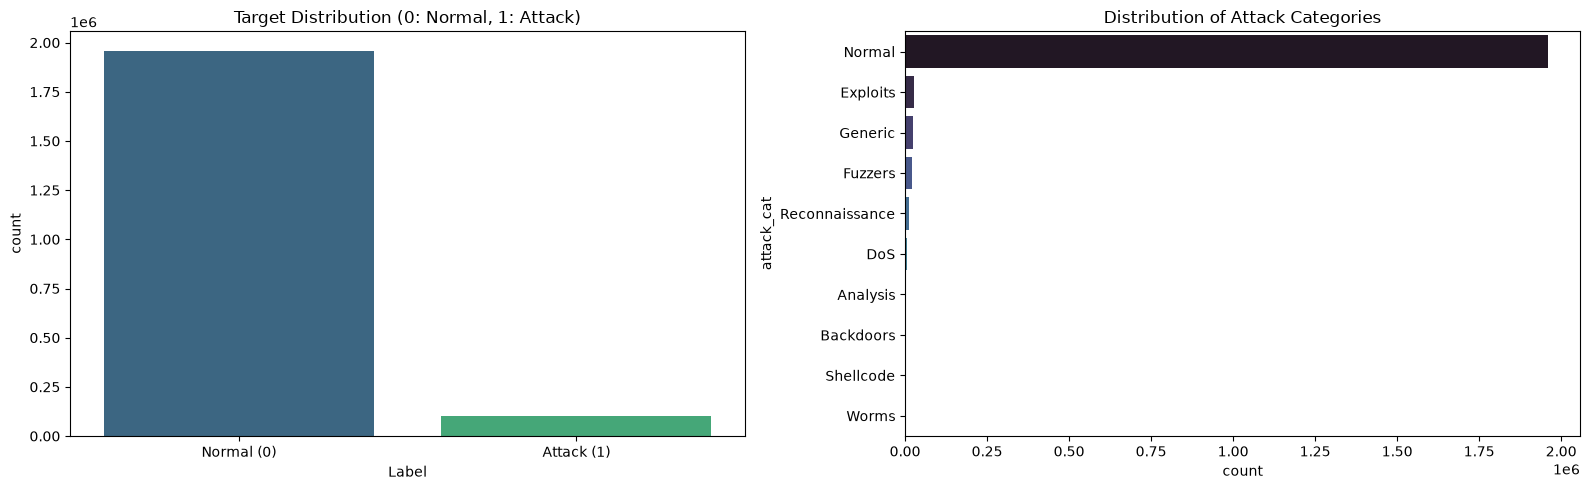

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=DataSet, x='Label', ax=axes[0], palette='viridis')
axes[0].set_title('Target Distribution (0: Normal, 1: Attack)')
axes[0].set_xticklabels(['Normal (0)', 'Attack (1)'])

sns.countplot(data=DataSet, y='attack_cat', ax=axes[1], order=DataSet['attack_cat'].value_counts().index, palette='mako')
axes[1].set_title('Distribution of Attack Categories')

plt.tight_layout()
plt.show()

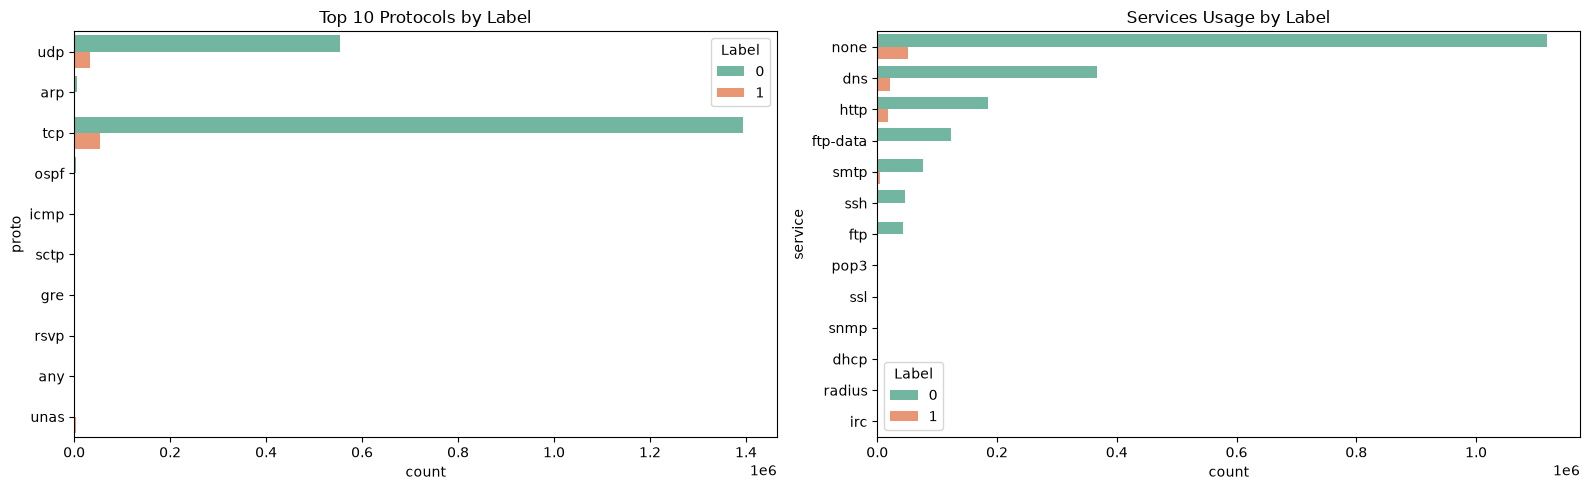

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_proto = DataSet['proto'].value_counts().head(10).index
sns.countplot(data=DataSet[DataSet['proto'].isin(top_proto)], y='proto', hue='Label', ax=axes[0], palette='Set2')
axes[0].set_title('Top 10 Protocols by Label')

sns.countplot(data=DataSet, y='service', hue='Label', ax=axes[1], order=DataSet['service'].value_counts().index, palette='Set2')
axes[1].set_title('Services Usage by Label')

plt.tight_layout()
plt.show()

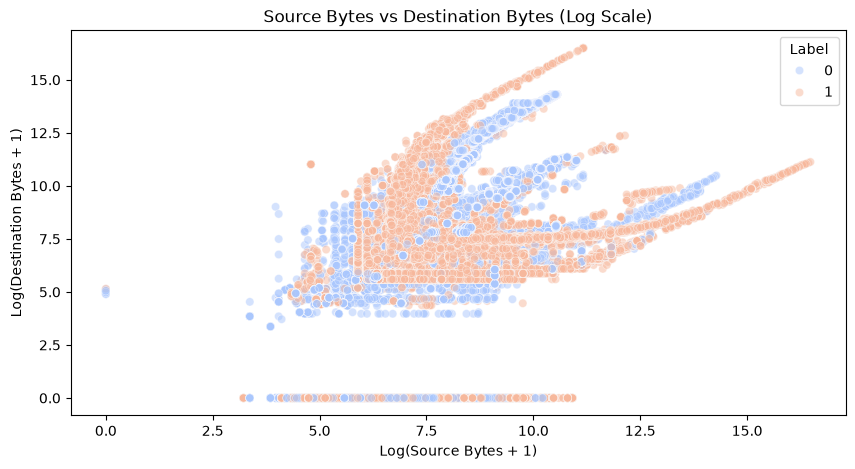

In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=DataSet, x=np.log1p(DataSet['sbytes']), y=np.log1p(DataSet['dbytes']), hue='Label', alpha=0.5, palette='coolwarm')
plt.title('Source Bytes vs Destination Bytes (Log Scale)')
plt.xlabel('Log(Source Bytes + 1)')
plt.ylabel('Log(Destination Bytes + 1)')
plt.show()

Top 10 characteristics associated with attacks:
Label               1.000000
sttl                0.765956
ct_state_ttl        0.685989
dttl                0.522135
tcprtt              0.283248
ackdat              0.278478
synack              0.246365
ct_dst_sport_ltm    0.245834
ct_dst_src_ltm      0.243373
Sload               0.225523
ct_src_dport_ltm    0.211701
Name: Label, dtype: float64


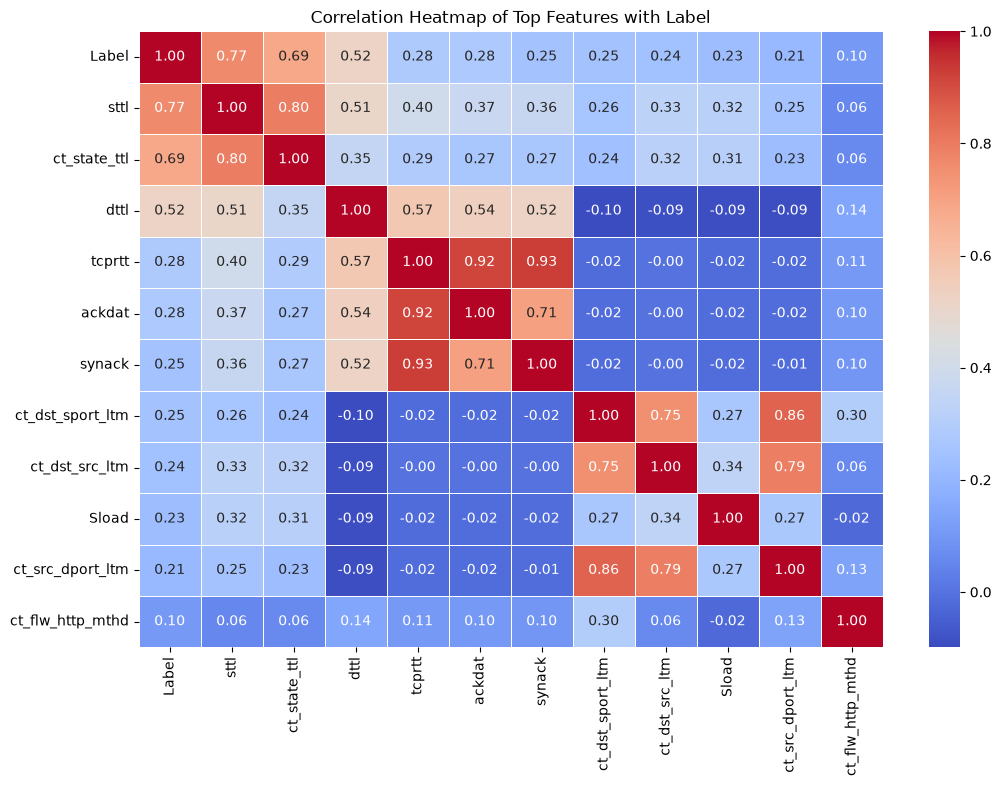

In [8]:
numeric_df = DataSet.select_dtypes(include=['int64', 'float64', 'Int64'])

corr_with_label = numeric_df.corr()['Label'].sort_values(ascending=False)

print("Top 10 characteristics associated with attacks:")
print(corr_with_label.head(11))

plt.figure(figsize=(12, 8))
top_corr_cols = corr_with_label.abs().head(12).index
sns.heatmap(numeric_df[top_corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Top Features with Label')
plt.show()

## Key Insights

**1. Severe class imbalance is the defining challenge of this dataset.**
Only ~4.8% of connections are labeled as attacks (95.2% Normal). This means
accuracy alone will be a misleading metric for any model — Precision, Recall,
and F1-score (especially per attack class) must be the primary evaluation
criteria, and resampling techniques (SMOTE, class weighting) should be
considered before training.

**2. Attack categories are themselves highly imbalanced.**
Exploits, Generic, and Fuzzers dominate the attack traffic, while Worms
(171 records) and Shellcode (1,511 records) are extremely rare. Any
multiclass model will struggle to learn these minority classes without
targeted handling (oversampling minority classes, class weights, or
merging very rare categories).

**3. TTL-related features are the strongest individual predictors of an attack.**
`sttl` (source TTL) has the highest correlation with the target (r ≈ 0.77),
followed by `ct_state_ttl` (r ≈ 0.69) and `dttl` (r ≈ 0.52). In practice,
attack traffic in this dataset clusters heavily around specific TTL values
(e.g. `sttl = 254`) that are rare in normal traffic — a strong, learnable
signal for the model.

**4. Many attacks receive no response from the destination.**
A large share of attack connections have `dbytes = 0` (no data returned by
the destination), consistent with reconnaissance/scanning-style attacks
that probe a target without completing a full exchange. This is visible in
the Source vs Destination Bytes scatter plot as a dense band of orange
(attack) points along `dbytes = 0`.

**5. TCP handshake timing features form a redundant cluster.**
`tcprtt`, `synack`, and `ackdat` are almost perfectly correlated with each
other (r > 0.9) and moderately correlated with the target. This is expected
since all three are derived from the same TCP handshake timing — during
feature selection for modeling, keeping just one (or combining them) can
reduce redundancy without losing signal.

**6. Protocol and service alone are weak predictors on their own, but a few rare values are near-perfect attack indicators.**
Common protocols/services (tcp, udp, dns, http) show attack rates close to
the dataset average (~2-5%). However, rare values like `proto = unas` and
`service = pop3` are associated with attack rates near 100% in this
dataset. These are useful signals but should be treated cautiously in
modeling — they are based on very small sample sizes and may not
generalize to unseen traffic.

**7. Feature groups behave very differently and may need different treatment.**
Byte/packet/duration features are heavily right-skewed (long-tailed),
suggesting log-transformation before modeling for distance-based or
linear models (though tree-based models are naturally robust to this
skew).